# MSD Decoder Workflow API

This notebook shows the compact workflow API for building MSD kernels, compiling
tasks, training MLD/MLE decoders, sampling evaluation data, evaluating curves,
and plotting results.

In [1]:
import math
import sys
from pathlib import Path

import numpy as np

PROJECT_ROOT_CANDIDATES = [Path.cwd(), Path.cwd().parent]
for candidate in PROJECT_ROOT_CANDIDATES:
    candidate = candidate.resolve()
    if (candidate / "demo" / "msd_utils").exists():
        sys.path.insert(0, str(candidate))
        break
else:
    raise FileNotFoundError("Could not locate repo root containing demo/msd_utils.")

LOCAL_DECODER_SRC_CANDIDATES = [
    Path.cwd() / ".." / "bloqade-decoders" / "src",
    Path.cwd() / "bloqade-decoders" / "src",
    Path.cwd().parent / "bloqade-decoders" / "src",
    Path.cwd().parent.parent / "bloqade-decoders" / "src",
]
for candidate in LOCAL_DECODER_SRC_CANDIDATES:
    candidate = candidate.resolve()
    if candidate.exists():
        sys.path.insert(0, str(candidate))
        break

from bloqade.decoders import GurobiDecoder, TableDecoder  # noqa: E402
from bloqade.lanes import GeminiLogicalSimulator  # noqa: E402
# NOTE, mtg: use a class? -- object-oriented methods? -- depends.
# use claude/codex? 
# NOTE, mtg: TaskBundle in the GeminiFrontend?-- make sure things are aligned?
# NOTE, mtg: change things in bundles? -- plural and make it an iterator?
# TODO: add sampling from the DEM directly-- jonathan's class in gemini_benchmarking? -- probably not; 
# can just use stim?
from demo.msd_utils import (  # noqa: E402
    DecoderCurveOptions,
    MSDDecoderWorkflowConfig,
    build_injected_tomography_kernels,
    build_injected_tomography_tasks,
    build_mle_decoder_suite,
    build_msd_tomography_kernels,
    build_msd_primitives,
    build_msd_tomography_tasks,
    evaluate_decoder_curves,
    evaluate_injected_baseline,
    plot_decoder_curves,
    sample_actual_data,
    train_mld_decoder_suite,
)

## User Configuration

In [2]:
mld_train_shots = 10_000_000
eval_shots = 1_000_000

ideal_theta = 0.3041 * math.pi
ideal_phi = 0.25 * math.pi
ideal_lam = 0.0

theta_offset = 0.30
phi_offset = 0.0
lam_offset = 0.0

theta = ideal_theta + theta_offset
phi = ideal_phi + phi_offset
lam = ideal_lam + lam_offset

target_bloch_vector = np.ones(3, dtype=np.float64) / np.sqrt(3.0)
decoder_primitive_set = build_msd_primitives(theta, phi, lam)
valid_factory_targets = np.array([[1, 0, 1, 1]], dtype=np.uint8)

config = MSDDecoderWorkflowConfig(
    # TODO, sm: separate the training shots from the MLD config and MLE config.
    mld_train_shots=mld_train_shots,
    # TODO, sm: put different concerns in different sections of the API. For the decoders.
    # TODO, sm: create different objects for separate concerns? -- separate out configs.
    eval_shots=eval_shots,
    target_bloch_vector=target_bloch_vector,
    theta=theta,
    phi=phi,
    lam=lam,
    # TODO, stefan mtg: don't call this a "primitive_set" ?
    decoder_primitive_set=decoder_primitive_set,
    valid_factory_targets=valid_factory_targets,
    num_logical_qubits=5,
    output_qubit=0,
    # Use prefix-prepare special tasks so MLD table-training data stays on a
    # smaller special path. Actual/ranking/evaluation data uses CliffT below.
    special_kernel_strategy="compiled_inverse_prefix",
    # Use CliffT for the noisy non-Clifford actual/evaluation sampling path.
    # The tsim detector sampler can hit a normalization-underflow assertion on
    # these circuits.
    sim_type="clifft",
    binary_precision=4,
    log=True,
)

Building MSD primitives...


## Kernels And Tasks

In [3]:
simulator = GeminiLogicalSimulator()

msd_tomography_kernels = build_msd_tomography_kernels(config)
injected_tomography_kernels = build_injected_tomography_kernels(config)

msd_tomography_tasks = build_msd_tomography_tasks(
    simulator,
    config,
    msd_tomography_kernels,
)
injected_tomography_tasks = build_injected_tomography_tasks(
    simulator,
    config,
    injected_tomography_kernels,
)

Building MSD tomography kernels...
Building injected tomography kernels...
Building MSD simulator tasks...
Building injected simulator tasks...


## Decoder Training

In [4]:
mld_decoders = train_mld_decoder_suite(
    msd_tomography_tasks,
    config,
    table_decoder_cls=TableDecoder,
)

mle_decoders = build_mle_decoder_suite(
    msd_tomography_tasks,
    gurobi_decoder_cls=GurobiDecoder,
)

Sampling MLD table-training data for X with 10,000,000 shots...


MLD X: table-training samples:   0%|          | 0/10000000 [00:00<?, ?shots/s]

Sampling MLD table-training data for Y with 10,000,000 shots...


MLD Y: table-training samples:   0%|          | 0/10000000 [00:00<?, ?shots/s]

Sampling MLD table-training data for Z with 10,000,000 shots...


...

Sampling MLD ranking data for Y with 10,000,000 shots...


MLD Y: ranking samples:   0%|          | 0/10000000 [00:00<?, ?shots/s]

Sampling MLD ranking data for Z with 10,000,000 shots...


MLD Z: ranking samples:   0%|          | 0/10000000 [00:00<?, ?shots/s]

Training MLD table decoders for X...
Preparing MLD table-training arrays for X...
Training full MLD table decoder for X from 10,000,000 shots...
Training factory MLD table decoder for X from 10,000,000 shots...
Finished MLD table decoders for X.
Training MLD table decoders for Y...
Preparing MLD table-training arrays for Y...
Training full MLD table decoder for Y from 10,000,000 shots...
Training factory MLD table decoder for Y from 10,000,000 shots...
Finished MLD table decoders for Y.
Training MLD table decoders for Z...
Preparing MLD table-training arrays for Z...
Training full MLD table decoder for Z from 10,000,000 shots...
Training factory MLD table decoder for Z from 10,000,000 shots...
Finished MLD table decoders for Z.
Estimating shared MLD ancilla-pattern fidelity scores...
Finished estimating shared MLD ancilla-pattern fidelity scores.
Assembling MLD decoder adapter for X...
Assembling MLD decoder adapter for Y...
Assembling MLD decoder adapter for Z...
Built MLD decoders wi

## Sampling, Curves, And Plot

In [5]:
injected_summary = evaluate_injected_baseline(
    injected_tomography_tasks,
    config,
    table_decoder_cls=TableDecoder,
    raw=False,
)

Evaluating corrected injected baseline...


In [6]:
injected_summary

{'point': 0.9651497499261216,
 'median': 0.9651497499261216,
 'low': 0.9643387538132857,
 'high': 0.9659607460389574,
 'error': 0.0008109961128358213,
 'bloch': (0.653824, 0.651272, 0.30623)}

Sampling actual data for X with 1,000,000 shots...
Sampling actual data for Y with 1,000,000 shots...
Sampling actual data for Z with 1,000,000 shots...
Evaluating MLD curve...
Evaluating MLE curve...


MLE X: factory decode:   0%|          | 0/1000000 [00:00<?, ?shots/s]

MLE Y: factory decode:   0%|          | 0/1000000 [00:00<?, ?shots/s]

MLE Z: factory decode:   0%|          | 0/1000000 [00:00<?, ?shots/s]

Plotting decoder curves...


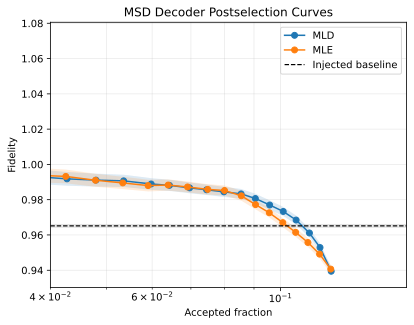

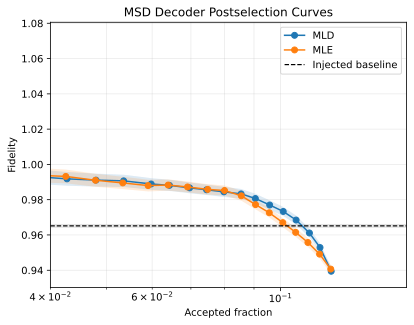

In [7]:
# NOTE, mtg: add a log for when MLE decoder starts or ends
# NOTE, mtg: can show a progress bar?
# NOTE, mtg: if something runs -- takes 6 minutes -- can split it into extra blocks in the notebook?
actual_data = sample_actual_data(msd_tomography_tasks, config)

curves = evaluate_decoder_curves(
    actual_data,
    {
        "MLD": mld_decoders,
        "MLE": mle_decoders,
    },
    config,
    curve_options=DecoderCurveOptions(
        threshold_points=24,
        threshold_policy="quantile",
        selection_mode="threshold",
    ),
)

# TODO: subset the curves so that things under the "min_accepted_fraction" just aren't plotted at all
# on the curve
fig, ax = plot_decoder_curves(
    curves,
    injected_summary=injected_summary,
    title="MSD Decoder Postselection Curves",
)
fig